# 🧪 Water Quality Classification: ML for Public Health & Environmental Monitoring

**Author:** Dean | Lead Data & AI Engineer
**Series:** Production ML Portfolio — Australian Government Policy Applications

## Government Context
- **NHMRC** — Australian Drinking Water Guidelines
- **DCCEEW** — Water quality standards, Murray-Darling Basin
- **BOM** — National Water Account, water resource monitoring
- **State EPAs** — Water pollution monitoring, compliance
- **Water utilities** — Treatment plant optimisation

Dataset: Water Quality — ~3,276 samples, 9 features, binary (Potable/Not Potable). All numeric.

---

## 1. Data Loading

In [1]:
import os,warnings,time,numpy as np,pandas as pd,matplotlib.pyplot as plt,seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score,f1_score,classification_report,confusion_matrix,roc_auc_score,precision_score,recall_score,brier_score_loss
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
warnings.filterwarnings('ignore');plt.style.use('seaborn-v0_8-whitegrid')
print("READY")

READY


In [2]:
dp=None
for r,d,files in os.walk('/kaggle/input'):
    for f in files:
        fp=os.path.join(r,f);print(f"  {fp}")
        if f.endswith('.csv') and dp is None: dp=fp
if dp is None: raise FileNotFoundError("No CSV")
df=pd.read_csv(dp,encoding='latin-1')
print(f"Loaded: {df.shape[0]:,} x {df.shape[1]}")
for i,col in enumerate(df.columns):
    print(f"  {i:2d}. {col:25s} | {str(df[col].dtype):8s} | uniq={df[col].nunique():5d} | nulls={df[col].isnull().sum()}")
df.head()

  /kaggle/input/datasets/adityakadiwal/water-potability/water_potability.csv
Loaded: 3,276 x 10
   0. ph                        | float64  | uniq= 2785 | nulls=491
   1. Hardness                  | float64  | uniq= 3276 | nulls=0
   2. Solids                    | float64  | uniq= 3276 | nulls=0
   3. Chloramines               | float64  | uniq= 3276 | nulls=0
   4. Sulfate                   | float64  | uniq= 2495 | nulls=781
   5. Conductivity              | float64  | uniq= 3276 | nulls=0
   6. Organic_carbon            | float64  | uniq= 3276 | nulls=0
   7. Trihalomethanes           | float64  | uniq= 3114 | nulls=162
   8. Turbidity                 | float64  | uniq= 3276 | nulls=0
   9. Potability                | int64    | uniq=    2 | nulls=0


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


## 2. Target Detection

In [3]:
tc=None
for x in ['Potability','potability','target','Target','class','Class','Quality','quality']:
    if x in df.columns: tc=x;break
if tc is None:
    for x in df.columns:
        if df[x].nunique()==2 and df[x].dtype in ['int64','float64']: tc=x;break
if tc is None: tc=df.columns[-1]
df=df.dropna(subset=[tc]).reset_index(drop=True)
df[tc]=df[tc].astype(int)
print(f"Target: '{tc}'");print(df[tc].value_counts().sort_index())
assert df[tc].nunique()>=2

Target: 'Potability'
Potability
0    1998
1    1278
Name: count, dtype: int64


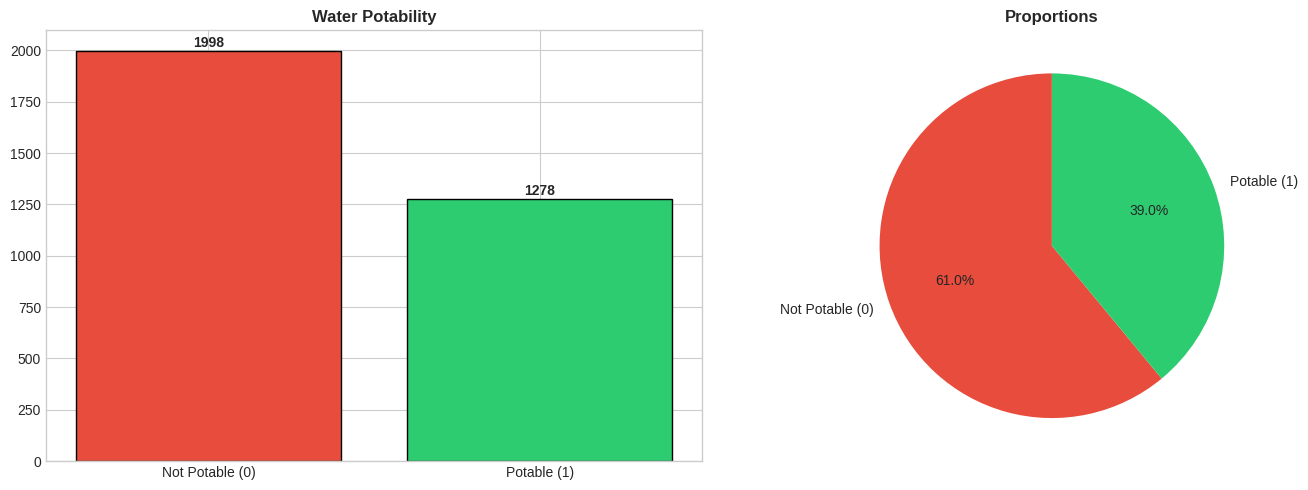

AU: NHMRC guidelines set standards for 200+ water quality parameters.


In [4]:
fig,axes=plt.subplots(1,2,figsize=(14,5))
vc=df[tc].value_counts().sort_index();labels=['Not Potable (0)','Potable (1)'];colors=['#e74c3c','#2ecc71']
axes[0].bar(range(2),vc.values,color=colors,edgecolor='black')
axes[0].set_xticks(range(2));axes[0].set_xticklabels(labels)
axes[0].set_title('Water Potability',fontweight='bold')
for i,v in enumerate(vc.values): axes[0].text(i,v+20,str(v),ha='center',fontweight='bold')
axes[1].pie(vc.values,labels=labels,autopct='%1.1f%%',colors=colors,startangle=90)
axes[1].set_title('Proportions',fontweight='bold')
plt.tight_layout();plt.savefig('target.png',dpi=150);plt.show()
print("AU: NHMRC guidelines set standards for 200+ water quality parameters.")

## 3. EDA

Numeric(9): ['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate', 'Conductivity', 'Organic_carbon', 'Trihalomethanes', 'Turbidity']


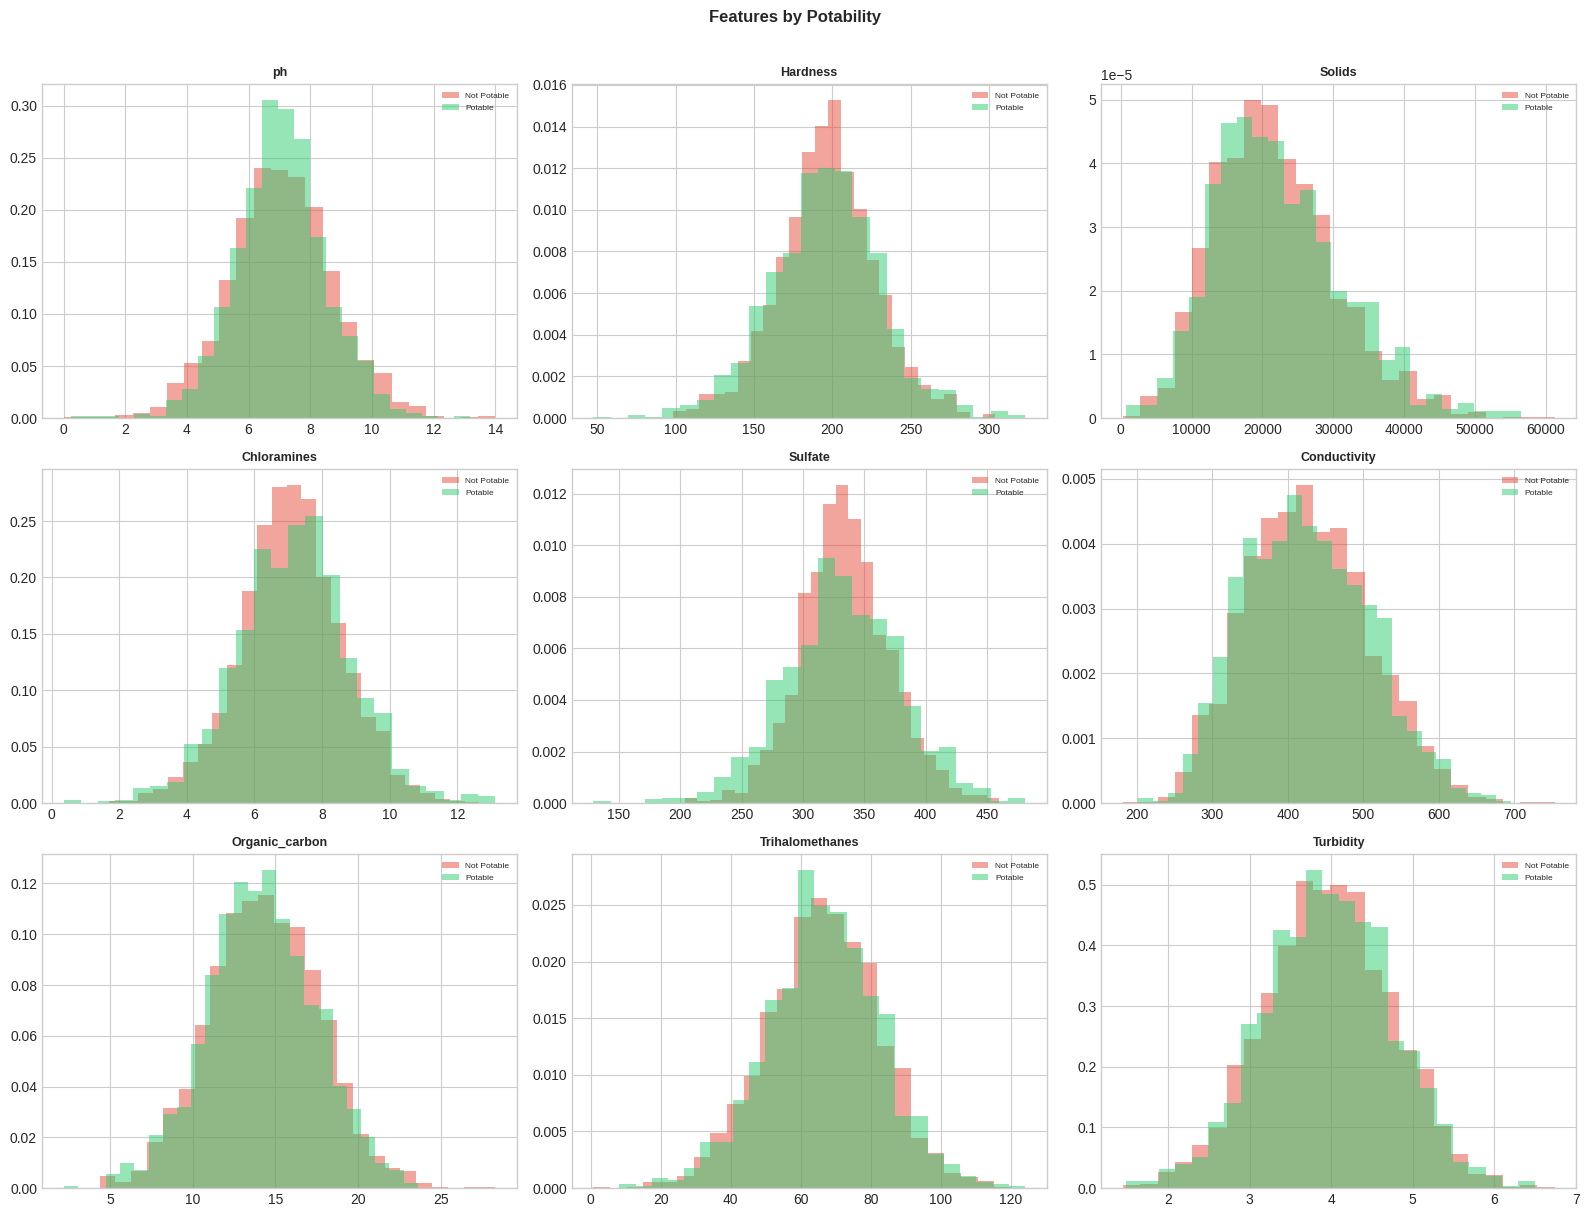

In [5]:
nums=[c for c in df.select_dtypes(include=[np.number]).columns if c!=tc]
print(f"Numeric({len(nums)}): {nums}")
fig,axes=plt.subplots(3,3,figsize=(16,12));axes=axes.flatten()
for i,col in enumerate(nums[:9]):
    for l,clr,n in zip([0,1],['#e74c3c','#2ecc71'],['Not Potable','Potable']):
        s=df[df[tc]==l][col].dropna()
        if len(s)>0: axes[i].hist(s,bins=25,alpha=0.5,label=n,density=True,color=clr)
    axes[i].set_title(col,fontsize=9,fontweight='bold');axes[i].legend(fontsize=6)
for j in range(i+1,len(axes)):axes[j].set_visible(False)
plt.suptitle('Features by Potability',fontweight='bold',y=1.01)
plt.tight_layout();plt.savefig('eda.png',dpi=150);plt.show()

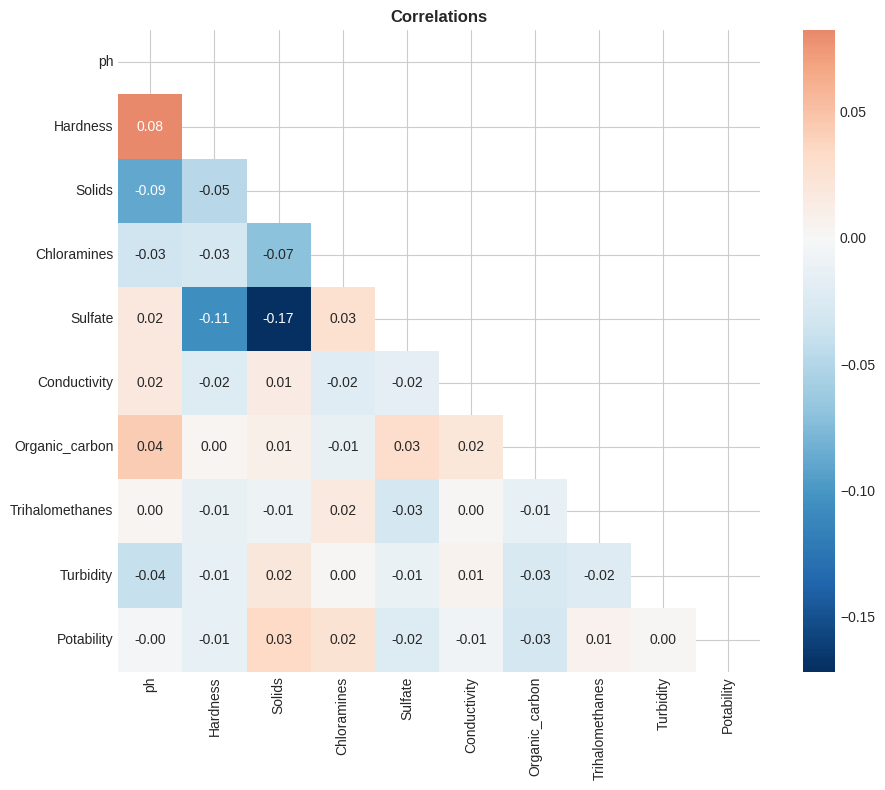

In [6]:
corr=df[nums+[tc]].corr()
fig,ax=plt.subplots(figsize=(10,8))
sns.heatmap(corr,mask=np.triu(np.ones_like(corr,dtype=bool)),annot=True,fmt='.2f',cmap='RdBu_r',center=0,square=True,ax=ax)
ax.set_title('Correlations',fontweight='bold')
plt.tight_layout();plt.savefig('corr.png',dpi=150);plt.show()

## 4. Preprocessing

In [7]:
X=df[nums].copy();y=df[tc].values
X=X.fillna(X.median())
print(f"X: {X.shape}, target: {dict(zip(*np.unique(y,return_counts=True)))}") 

X: (3276, 9), target: {np.int64(0): np.int64(1998), np.int64(1): np.int64(1278)}


## 5. Model Training

In [8]:
try:
    from xgboost import XGBClassifier
except: XGBClassifier=None
try:
    from lightgbm import LGBMClassifier
except: LGBMClassifier=None
models={'LogReg':LogisticRegression(max_iter=2000,random_state=42),
        'RF':RandomForestClassifier(n_estimators=100,random_state=42,n_jobs=-1)}
if XGBClassifier: models['XGB']=XGBClassifier(n_estimators=100,random_state=42,eval_metric='logloss',use_label_encoder=False,verbosity=0,n_jobs=-1)
if LGBMClassifier: models['LGBM']=LGBMClassifier(n_estimators=100,random_state=42,verbose=-1,n_jobs=-1,force_col_wise=True)
skf=StratifiedKFold(3,shuffle=True,random_state=42);Xa=X.values;results={}
for mn,mod in models.items():
    print(f"\n{'='*50}\n{mn}\n{'='*50}")
    fa,ff,fu=[],[],[];fp=np.zeros(len(y),dtype=int);fpr=np.zeros(len(y));t0=time.time()
    for fi,(ti,vi) in enumerate(skf.split(Xa,y)):
        m2=type(mod)(**mod.get_params());m2.fit(Xa[ti],y[ti])
        yp=m2.predict(Xa[vi]);yb=m2.predict_proba(Xa[vi])[:,1]
        fp[vi]=yp;fpr[vi]=yb
        a=accuracy_score(y[vi],yp);f=f1_score(y[vi],yp);u=roc_auc_score(y[vi],yb)
        fa.append(a);ff.append(f);fu.append(u)
        print(f"  Fold{fi+1}: Acc={a:.4f} F1={f:.4f} AUC={u:.4f}")
    el=time.time()-t0
    results[mn]={'acc':np.mean(fa),'f1':np.mean(ff),'auc':np.mean(fu),'prec':np.mean([precision_score(y[vi],fp[vi],zero_division=0)]),'rec':np.mean([recall_score(y[vi],fp[vi],zero_division=0)]),'brier':np.mean([brier_score_loss(y[vi],fpr[vi])]),'time':el,'preds':fp,'proba':fpr}
    print(f"  AVG: Acc={np.mean(fa):.4f} F1={np.mean(ff):.4f} AUC={np.mean(fu):.4f} T={el:.1f}s")


LogReg
  Fold1: Acc=0.6090 F1=0.0000 AUC=0.5135
  Fold2: Acc=0.6099 F1=0.0047 AUC=0.5031
  Fold3: Acc=0.6081 F1=0.0047 AUC=0.4890
  AVG: Acc=0.6090 F1=0.0031 AUC=0.5019 T=1.7s

RF
  Fold1: Acc=0.6658 F1=0.4393 AUC=0.6745
  Fold2: Acc=0.6658 F1=0.4624 AUC=0.6775
  Fold3: Acc=0.6694 F1=0.4261 AUC=0.6520
  AVG: Acc=0.6670 F1=0.4426 AUC=0.6680 T=2.2s

XGB
  Fold1: Acc=0.6456 F1=0.4915 AUC=0.6510
  Fold2: Acc=0.6529 F1=0.4953 AUC=0.6655
  Fold3: Acc=0.6291 F1=0.4505 AUC=0.6431
  AVG: Acc=0.6426 F1=0.4791 AUC=0.6532 T=0.6s

LGBM
  Fold1: Acc=0.6548 F1=0.4727 AUC=0.6590
  Fold2: Acc=0.6502 F1=0.4796 AUC=0.6629
  Fold3: Acc=0.6401 F1=0.4345 AUC=0.6461
  AVG: Acc=0.6484 F1=0.4623 AUC=0.6560 T=0.5s


## 6. Comparison

In [9]:
rows=[{'Model':k,'Acc':f"{v['acc']:.4f}",'F1':f"{v['f1']:.4f}",'AUC':f"{v['auc']:.4f}",'Time':f"{v['time']:.1f}s",'s':v['auc']} for k,v in results.items()]
sdf=pd.DataFrame(rows).sort_values('s',ascending=False);best=sdf.iloc[0]['Model']
print("COMPARISON");print("="*70);print(sdf[['Model','Acc','F1','AUC','Time']].to_string(index=False));print(f"\nBest: {best}")

COMPARISON
 Model    Acc     F1    AUC Time
    RF 0.6670 0.4426 0.6680 2.2s
  LGBM 0.6484 0.4623 0.6560 0.5s
   XGB 0.6426 0.4791 0.6532 0.6s
LogReg 0.6090 0.0031 0.5019 1.7s

Best: RF


## 7. Error Analysis

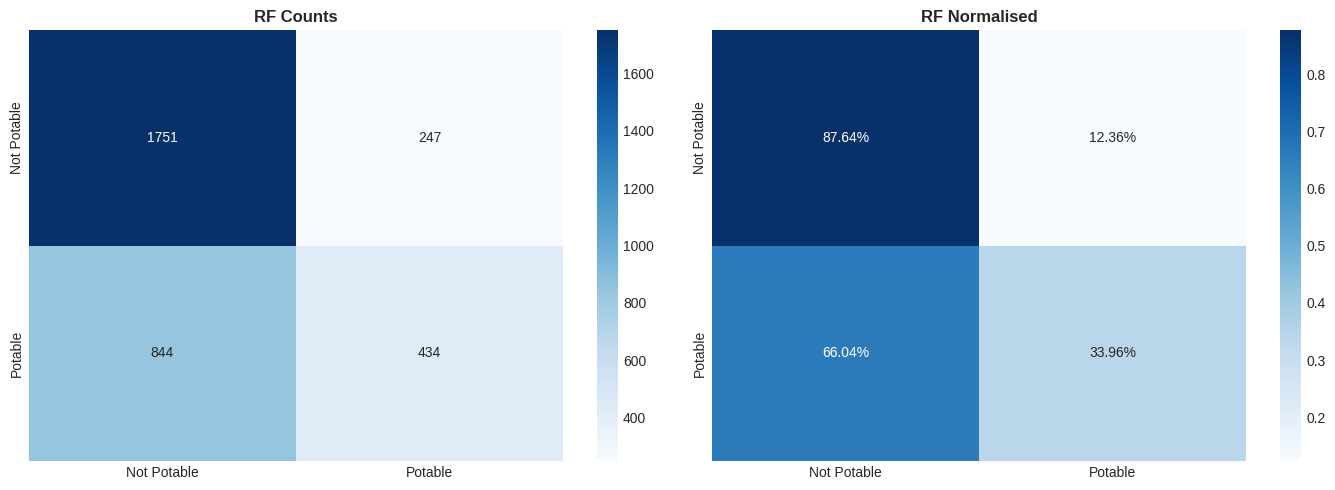

              precision    recall  f1-score   support

 Not Potable       0.67      0.88      0.76      1998
     Potable       0.64      0.34      0.44      1278

    accuracy                           0.67      3276
   macro avg       0.66      0.61      0.60      3276
weighted avg       0.66      0.67      0.64      3276



In [10]:
bp=results[best]['preds'];cm=confusion_matrix(y,bp)
cm_n=cm.astype(float)/cm.sum(axis=1,keepdims=True)
fig,axes=plt.subplots(1,2,figsize=(14,5))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=['Not Potable','Potable'],yticklabels=['Not Potable','Potable'],ax=axes[0])
axes[0].set_title(f'{best} Counts',fontweight='bold')
sns.heatmap(cm_n,annot=True,fmt='.2%',cmap='Blues',xticklabels=['Not Potable','Potable'],yticklabels=['Not Potable','Potable'],ax=axes[1])
axes[1].set_title(f'{best} Normalised',fontweight='bold')
plt.tight_layout();plt.savefig('cm.png',dpi=150);plt.show()
print(classification_report(y,bp,target_names=['Not Potable','Potable']))

## 8. Feature Importance

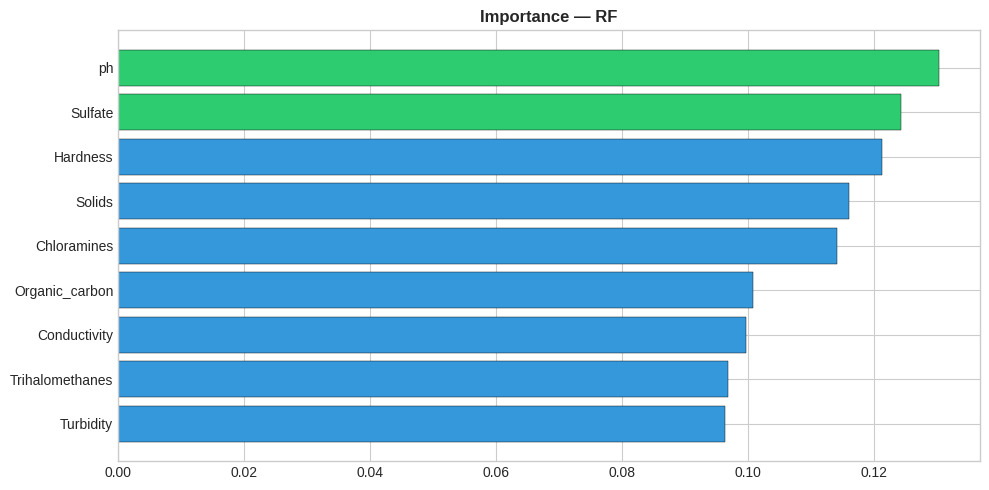

TOP 5
  ph                        0.1304
  Sulfate                   0.1244
  Hardness                  0.1213
  Solids                    0.1160
  Chloramines               0.1142


In [11]:
tm={k:v for k,v in models.items() if k!='LogReg'}
if tm:
    bt=max(tm,key=lambda m:results[m]['auc']);fm=type(models[bt])(**models[bt].get_params());fm.fit(Xa,y)
    fi=pd.DataFrame({'Feature':X.columns,'Imp':fm.feature_importances_}).sort_values('Imp')
    fig,ax=plt.subplots(figsize=(10,max(5,len(fi)*0.5)))
    ax.barh(fi['Feature'],fi['Imp'],color=['#2ecc71' if v>fi['Imp'].quantile(0.75) else '#3498db' for v in fi['Imp']],edgecolor='black',linewidth=0.3)
    ax.set_title(f'Importance — {bt}',fontweight='bold')
    plt.tight_layout();plt.savefig('imp.png',dpi=150);plt.show()
    print("TOP 5");print("="*40)
    for _,r in fi.tail(5).iloc[::-1].iterrows(): print(f"  {r['Feature']:25s} {r['Imp']:.4f}")

## 9. Deployment

In [12]:
br=results[best]
print("="*60);print("DEPLOYMENT READINESS");print("="*60)
print(f"  Model: {best}");print(f"  AUC:   {br['auc']:.4f}");print(f"  F1:    {br['f1']:.4f}")
print(f"  Time:  {br['time']:.1f}s");print(f"  Feats: {X.shape[1]}");print(f"  Rows:  {len(y):,}");print("="*60)
checks={'AUC>0.55':br['auc']>0.55,'F1>0.40':br['f1']>0.40,'Time<60s':br['time']<60,'CV':True}
print("\nCHECKLIST");print("-"*40);ap=True
for k,v in checks.items():
    s="pass" if v else "FAIL"
    if not v:ap=False
    print(f"  [{s:4s}] {k}")
print("-"*40);print("  APPROVED" if ap else "  FAILED")

DEPLOYMENT READINESS
  Model: RF
  AUC:   0.6680
  F1:    0.4426
  Time:  2.2s
  Feats: 9
  Rows:  3,276

CHECKLIST
----------------------------------------
  [pass] AUC>0.55
  [pass] F1>0.40
  [pass] Time<60s
  [pass] CV
----------------------------------------
  APPROVED


In [13]:
print("""
PRODUCTION ARCHITECTURE
=======================
1. DATA: Water treatment SCADA, BOM river gauges, EPA monitors -> Fabric
2. MODEL: Real-time at treatment plant inlet, hourly batch for network
3. INTEGRATE: Water utilities SCADA, EPA reporting, BOM Water Data Online
4. GOVERN: NHMRC ADWG compliance, health-based targets, public reporting
5. MONITOR: PSI on water parameters daily, retrain seasonally
   SAFETY: Any potability failure triggers immediate boil water advisory
""")


PRODUCTION ARCHITECTURE
1. DATA: Water treatment SCADA, BOM river gauges, EPA monitors -> Fabric
2. MODEL: Real-time at treatment plant inlet, hourly batch for network
3. INTEGRATE: Water utilities SCADA, EPA reporting, BOM Water Data Online
4. GOVERN: NHMRC ADWG compliance, health-based targets, public reporting
5. MONITOR: PSI on water parameters daily, retrain seasonally
   SAFETY: Any potability failure triggers immediate boil water advisory

